# NDCG@k (Normalized Discounted Cumulative Gain) - Comprehensive Guide

**A complete educational resource covering theory, implementation, and practical applications**

---

#### What is NDCG@k?

**Normalized Discounted Cumulative Gain at k (NDCG@k)** is a ranking evaluation metric that measures the quality of a ranked list by considering both:
- **Relevance**: How relevant each item is (graded relevance scores)
- **Position**: Items ranked higher are more valuable (logarithmic discount)

Unlike binary metrics (Precision@k, Recall@k), NDCG@k handles **graded relevance** where items can have different levels of relevance (e.g., highly relevant=3, somewhat relevant=2, slightly relevant=1, not relevant=0).

**Key Advantages:**
- ✅ Handles graded relevance (not just binary relevant/irrelevant)
- ✅ Position-aware (ranking order matters)
- ✅ Normalized (comparable across different queries/datasets)
- ✅ Widely used standard in information retrieval and recommendation systems

#### Mathematical Foundation

NDCG@k is built from three components:

**1. Discounted Cumulative Gain (DCG@k):**
$$DCG@k = \sum_{i=1}^{k} \frac{rel_i}{\log_2(i+1)}$$

**2. Ideal DCG (IDCG@k):**
$$IDCG@k = \sum_{i=1}^{k} \frac{rel^*_i}{\log_2(i+1)}$$
where $rel^*_i$ are relevance scores sorted in descending order

**3. Normalized DCG (NDCG@k):**
$$NDCG@k = \frac{DCG@k}{IDCG@k}$$

**Key Concepts:**
- **$rel_i$**: Relevance score of item at position i
- **$\log_2(i+1)$**: Logarithmic discount factor (position penalty)
- **Normalization**: Ensures NDCG@k ∈ [0, 1], with 1 being perfect ranking
- **Position Penalty**: Items at lower positions contribute less to the score

#### Intuition Behind NDCG@k Calculation
---

**Why This Formula Makes Sense:**

The NDCG@k formula might look complex, but each component has a clear purpose that mirrors how users actually interact with ranked lists:

**The Three Key Insights:**

**1. Graded Relevance (rel_i)**
- **Real life**: Not all relevant items are equally useful
- **Example**: When searching "Python tutorials", a beginner-friendly tutorial (rel=3) is more valuable than a brief mention in a blog post (rel=1)
- **Formula impact**: Higher relevance scores contribute more to the total score

**2. Position Penalty (1/log₂(i+1))**
- **Real life**: Users pay more attention to top results
- **Example**: Position 1 gets discount factor 1.0, position 2 gets 0.63, position 3 gets 0.5
- **Formula impact**: Items ranked higher get less "discounting" (penalty)

**3. Normalization (DCG/IDCG)**
- **Real life**: We want to compare performance across different queries
- **Example**: Query A has 10 relevant items, Query B has 3 - raw scores aren't comparable
- **Formula impact**: Converts to 0-1 scale where 1.0 = perfect ranking

In [1]:
# Visual demonstration of NDCG@k intuition
import numpy as np
import matplotlib.pyplot as plt
from math import log2

MOVIE RECOMMENDATION EXAMPLE
User's True Preferences:
  The Godfather: 5 stars
  Toy Story: 3 stars
  The Matrix: 5 stars
  Casablanca: 4 stars
  Frozen: 2 stars

System's Recommendation Order:
  1. The Godfather (User would rate: 5 stars)
  2. The Matrix (User would rate: 5 stars)
  3. Toy Story (User would rate: 3 stars)

STEP 1: Relevance Values (top 3)
Predicted ranking relevance: [5, 5, 3]
This means our system put items with relevance [5, 5, 3] in the top 3 positions

STEP 2: Position Discount Factors (Why Position Matters)
💡 **Intuition**: Users pay MUCH more attention to top results!
   • Position 1: Gets 100% attention (no discount)
   • Position 2: Gets ~63% attention (moderate discount)
   • Position 3: Gets ~50% attention (higher discount)
   • Lower positions: Get exponentially less attention

**Mathematical Calculation**:
  Position 1: 1/log₂(1+1) = 1/log₂(2) = 1.000
              → User attention: ~100%
              → Users ALWAYS see this (prime real estate!)

  Positi

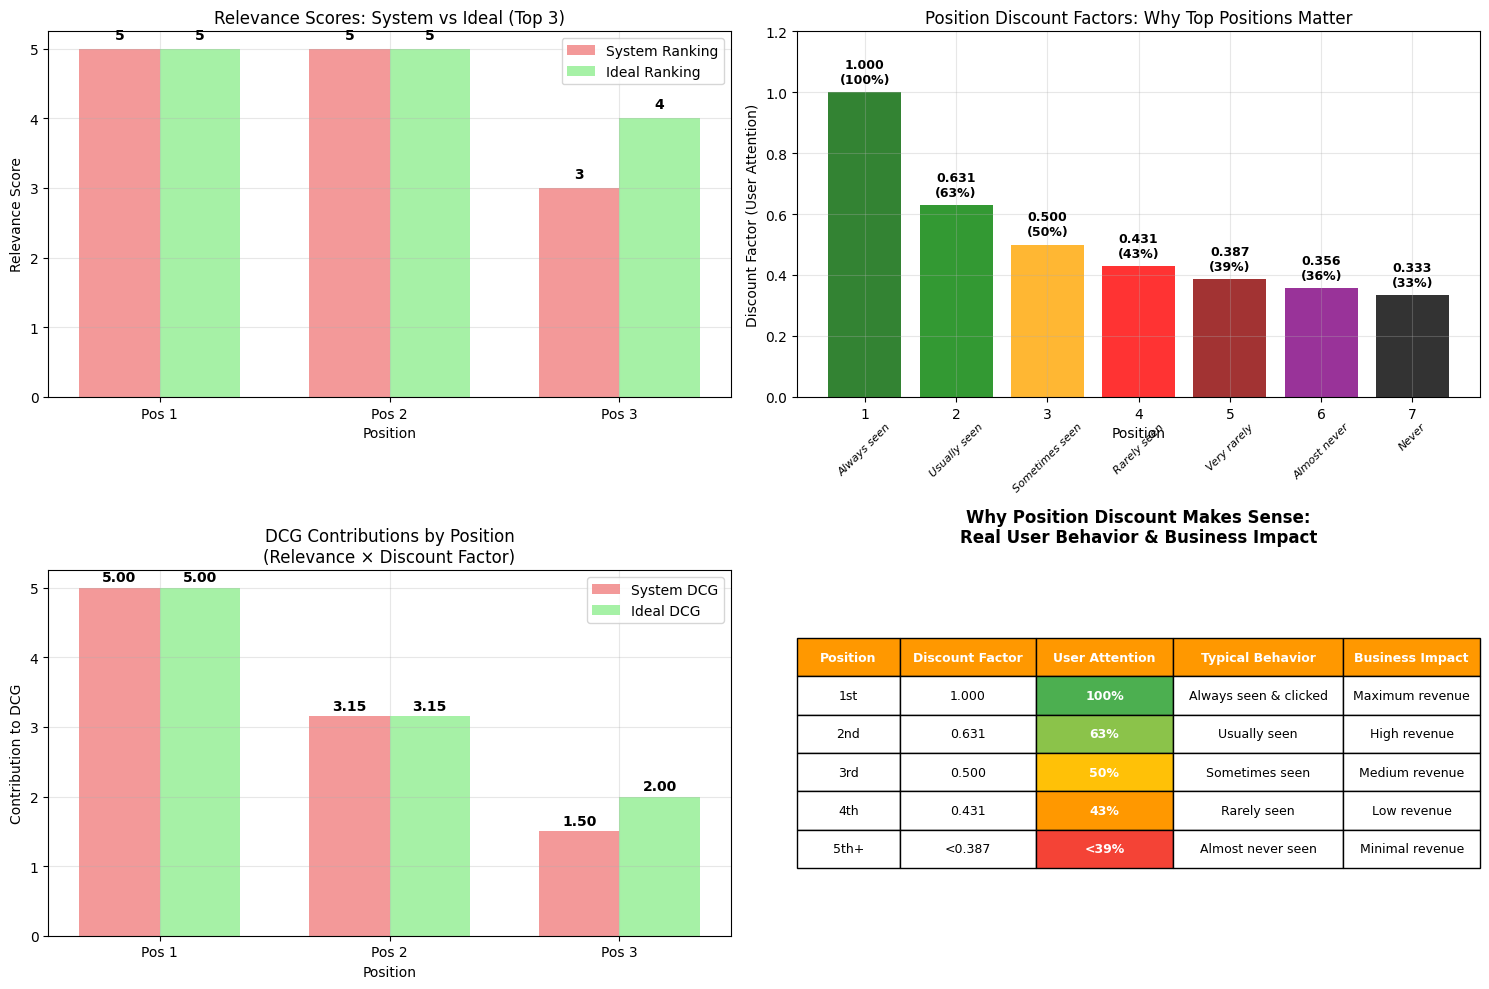


💡 KEY INSIGHTS FROM THIS EXAMPLE:
1. **Relevance matters**: Higher-rated movies contribute more to the score
2. **Position matters MORE**: Top positions get exponentially more weight
3. **Mathematical precision**: log₂ discount matches real user behavior
4. **Normalization enables comparison**: 0.0-1.0 scale is universally interpretable
5. **Perfect score is rare**: Even good rankings rarely achieve NDCG@k = 1.0
6. **Business relevance**: Position 1 vs 2 can mean huge revenue differences!


In [2]:
def demonstrate_ndcg_intuition():
    """
    Show step-by-step how NDCG@k calculation reflects real user behavior
    """
       
    # Example: Movie recommendation with star ratings
    movies = ["The Godfather", "Toy Story", "The Matrix", "Casablanca", "Frozen"]
    
    true_ratings    = [5, 3, 5, 4, 2]  # User's actual preferences (1-5 stars)
    predicted_order = [0, 2, 1, 3, 4]  # System's recommendation order (indices)
    
    print("MOVIE RECOMMENDATION EXAMPLE")
    print("=" * 50)
    print("User's True Preferences:")
    for i, (movie, rating) in enumerate(zip(movies, true_ratings)):
        print(f"  {movie}: {rating} stars")
    
    print(f"\nSystem's Recommendation Order:")
    for rank, idx in enumerate(predicted_order[:3], 1):
        movie  = movies[idx]
        rating = true_ratings[idx]
        print(f"  {rank}. {movie} (User would rate: {rating} stars)")
    
    k = 3
    
    # Step 1: Show relevance values
    print(f"\nSTEP 1: Relevance Values (top {k})")
    predicted_relevance = [true_ratings[i] for i in predicted_order]
    print(f"Predicted ranking relevance: {predicted_relevance[:k]}")
    print("This means our system put items with relevance [5, 5, 3] in the top 3 positions")
    
    # Step 2: Show position discounts - ENHANCED EXPLANATION
    print(f"\nSTEP 2: Position Discount Factors (Why Position Matters)")
    print("=" * 55)
    positions = range(1, k+1)
    discounts = [1/log2(i+1) for i in positions]
    
    print("💡 **Intuition**: Users pay MUCH more attention to top results!")
    print("   • Position 1: Gets 100% attention (no discount)")
    print("   • Position 2: Gets ~63% attention (moderate discount)")  
    print("   • Position 3: Gets ~50% attention (higher discount)")
    print("   • Lower positions: Get exponentially less attention")
    
    print(f"\n**Mathematical Calculation**:")
    for pos, discount in zip(positions, discounts):
        attention_pct = discount * 100
        print(f"  Position {pos}: 1/log₂({pos}+1) = 1/log₂({pos+1}) = {discount:.3f}")
        print(f"              → User attention: ~{attention_pct:.0f}%")
        
        # Add intuitive explanation for each position
        if pos == 1:
            print(f"              → Users ALWAYS see this (prime real estate!)")
        elif pos == 2:
            print(f"              → Users usually see this (still very visible)")
        elif pos == 3:
            print(f"              → Users sometimes see this (need to scroll slightly)")
        print()
    
    print("**Why log₂?** It matches real user behavior studies!")
    print("   Research shows attention drops exponentially, not linearly.")
    
    # Step 3: Calculate DCG step by step
    print(f"\nSTEP 3: DCG@{k} Calculation (Putting It Together)")
    print("=" * 50)
    print("Formula: DCG = Σ(relevance × discount_factor)")
    print("We multiply each relevance score by its position discount:")
    
    dcg_components = []
    total_dcg = 0
    
    for i in range(k):
        rel          = predicted_relevance[i]
        discount     = discounts[i]
        contribution = rel * discount
        
        dcg_components.append(contribution)
        total_dcg += contribution
        
        print(f"\n  Position {i+1}: {rel} × {discount:.3f} = {contribution:.3f}")
        print(f"             ↳ Movie rating {rel} gets {discount:.3f} weight = {contribution:.3f} points")
    
    print(f"\n  📈 Total DCG@{k} = {' + '.join(f'{c:.3f}' for c in dcg_components)} = {total_dcg:.3f}")
    print(f"   Higher relevance in top positions = Higher DCG score!")
    
    # Step 4: Calculate IDCG (ideal ranking)
    print(f"\n STEP 4: IDCG@{k} (What's the BEST Possible Score?)")
    print("=" * 55)
    ideal_relevance = sorted(true_ratings, reverse=True)[:k]
    print(f"Perfect ranking would be: {ideal_relevance}")
    print(f"(Put highest ratings [5,5,4] in top positions)")
    
    idcg_components = []
    total_idcg      = 0
    
    for i in range(k):
        rel          = ideal_relevance[i]
        discount     = discounts[i]
        contribution = rel * discount
        idcg_components.append(contribution)
        total_idcg += contribution
        
        print(f"\n  Position {i+1}: {rel} × {discount:.3f} = {contribution:.3f}")
        print(f"             ↳ Perfect system puts rating {rel} here")
    
    print(f"\n   Perfect IDCG@{k} = {' + '.join(f'{c:.3f}' for c in idcg_components)} = {total_idcg:.3f}")
    
    # Step 5: Final NDCG calculation
    ndcg = total_dcg / total_idcg if total_idcg > 0 else 0
    
    print(f"\n STEP 5: NDCG@{k} (How Good Are We?)")
    print("=" * 40)
    print(f"NDCG@{k} = DCG@{k} / IDCG@{k}")
    print(f"NDCG@{k} = {total_dcg:.3f} / {total_idcg:.3f} = {ndcg:.3f}")
    print(f"\n **Interpretation**: Our system achieved {ndcg:.1%} of perfect ranking!")
    
    if ndcg > 0.9:
        print("   EXCELLENT: Near-perfect ranking!")
    elif ndcg > 0.8:
        print("   ✅ GOOD: High-quality recommendations")
    elif ndcg > 0.7:
        print("   ⚠️  OKAY: Room for improvement")
    else:
        print("   ❌ POOR: Significant optimization needed")
    
    # Visual comparison
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Relevance comparison
    x_pos = np.arange(k)
    width = 0.35
    
    ax1.bar(x_pos - width/2, predicted_relevance[:k], width, label='System Ranking', alpha=0.8, color='lightcoral')
    ax1.bar(x_pos + width/2, ideal_relevance, width, label='Ideal Ranking', alpha=0.8, color='lightgreen')
    
    # Add value labels on bars
    for i, (sys_val, ideal_val) in enumerate(zip(predicted_relevance[:k], ideal_relevance)):
        ax1.text(i - width/2, sys_val + 0.1, str(sys_val), ha='center', va='bottom', fontweight='bold')
        ax1.text(i + width/2, ideal_val + 0.1, str(ideal_val), ha='center', va='bottom', fontweight='bold')
    
    ax1.set_xlabel('Position')
    ax1.set_ylabel('Relevance Score')
    ax1.set_title(f'Relevance Scores: System vs Ideal (Top {k})')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'Pos {i+1}' for i in range(k)])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Enhanced discount factors visualization
    extended_positions = range(1, 8)  # Show more positions for better understanding
    extended_discounts = [1/log2(i+1) for i in extended_positions]
    
    colors = ['darkgreen', 'green', 'orange', 'red', 'darkred', 'purple', 'black']
    bars = ax2.bar(extended_positions, extended_discounts, alpha=0.8, color=colors)
    
    ax2.set_xlabel('Position')
    ax2.set_ylabel('Discount Factor (User Attention)')
    ax2.set_title('Position Discount Factors: Why Top Positions Matter')
    ax2.grid(True, alpha=0.3)
    
    # Add percentage labels and explanations
    explanations = ['Always seen', 'Usually seen', 'Sometimes seen', 
                   'Rarely seen', 'Very rarely', 'Almost never', 'Never']
    
    for i, (pos, discount, explanation) in enumerate(zip(extended_positions, extended_discounts, explanations)):
        # Value on top of bar
        ax2.text(pos, discount + 0.02, f'{discount:.3f}\n({discount*100:.0f}%)', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Explanation below x-axis
        ax2.text(pos, -0.08, explanation, ha='center', va='top', fontsize=8, 
                rotation=45, style='italic')
    
    ax2.set_ylim(0, max(extended_discounts) * 1.2)
    
    # 3. Contribution comparison with detailed labels
    ax3.bar(x_pos - width/2, dcg_components, width, label='System DCG', alpha=0.8, color='lightcoral')
    ax3.bar(x_pos + width/2, idcg_components, width, label='Ideal DCG', alpha=0.8, color='lightgreen')
    
    # Add value labels
    for i, (sys_contrib, ideal_contrib) in enumerate(zip(dcg_components, idcg_components)):
        ax3.text(i - width/2, sys_contrib + 0.05, f'{sys_contrib:.2f}', ha='center', va='bottom', fontweight='bold')
        ax3.text(i + width/2, ideal_contrib + 0.05, f'{ideal_contrib:.2f}', ha='center', va='bottom', fontweight='bold')
    
    ax3.set_xlabel('Position')
    ax3.set_ylabel('Contribution to DCG')
    ax3.set_title('DCG Contributions by Position\n(Relevance × Discount Factor)')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([f'Pos {i+1}' for i in range(k)])
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Enhanced user attention table
    ax4.axis('off')
    
    attention_data = [
        ["Position", "Discount Factor", "User Attention", "Typical Behavior", "Business Impact"],
        ["1st", "1.000", "100%", "Always seen & clicked", "Maximum revenue"],
        ["2nd", "0.631", "63%", "Usually seen", "High revenue"],
        ["3rd", "0.500", "50%", "Sometimes seen", "Medium revenue"],
        ["4th", "0.431", "43%", "Rarely seen", "Low revenue"],
        ["5th+", "<0.387", "<39%", "Almost never seen", "Minimal revenue"]
    ]
    
    table = ax4.table(cellText=attention_data, cellLoc='center', loc='center',
                     colWidths=[0.15, 0.2, 0.2, 0.25, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.2)
    
    # Style the header row
    for i in range(5):
        table[(0, i)].set_facecolor('#FF9800')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color code attention levels
    colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']
    for i in range(1, 6):
        table[(i, 2)].set_facecolor(colors[i-1])
        table[(i, 2)].set_text_props(weight='bold', color='white')
    
    ax4.set_title('Why Position Discount Makes Sense:\nReal User Behavior & Business Impact', 
                  fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Enhanced key insights
    print(f"\n💡 KEY INSIGHTS FROM THIS EXAMPLE:")
    print("=" * 50)
    print(f"1. **Relevance matters**: Higher-rated movies contribute more to the score")
    print(f"2. **Position matters MORE**: Top positions get exponentially more weight")
    print(f"3. **Mathematical precision**: log₂ discount matches real user behavior")
    print(f"4. **Normalization enables comparison**: 0.0-1.0 scale is universally interpretable")
    print(f"5. **Perfect score is rare**: Even good rankings rarely achieve NDCG@k = 1.0")
    print(f"6. **Business relevance**: Position 1 vs 2 can mean huge revenue differences!")

# Run the intuition demonstration
demonstrate_ndcg_intuition()

#### When to Use NDCG@k?

**Primary Use Cases:**

**1. Search Engines**
- Query: "machine learning tutorials"
- Results have different relevance levels (perfect match, good match, somewhat relevant)
- Top results are more valuable to users

**2. Recommendation Systems**
- Movie recommendations with star ratings
- Product recommendations with different appeal levels
- Content ranking where user engagement varies

**3. Ranking Problems**
- Document retrieval systems
- Learning-to-rank applications
- Personalized content curation

**4. A/B Testing**
- Comparing ranking algorithms
- Measuring ranking quality improvements
- Evaluating recommendation system changes

**❌ When NOT to use NDCG@k:**
- Binary relevance scenarios (use Precision@k, Recall@k)
- When position doesn't matter (use average metrics)
- When you need interpretability over accuracy (NDCG can be complex to explain)

In [6]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import log2
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("📚 Libraries imported successfully!")
print("🚀 Ready to explore NDCG@k!")

📚 Libraries imported successfully!
🚀 Ready to explore NDCG@k!


#### Core NDCG@k Implementation

In [5]:
def dcg_at_k(relevance_scores: List[float], k: int) -> float:
    """
    Calculate Discounted Cumulative Gain at k
    
    Args:
        relevance_scores: List of relevance scores in ranked order
        k: Number of top items to consider
    
    Returns:
        DCG@k score
    """
    if k <= 0:
        return 0.0
    
    # Take only top k items
    relevance_k = relevance_scores[:k]
    
    # Calculate DCG with logarithmic discount
    dcg = sum(rel / log2(i + 2) for i, rel in enumerate(relevance_k))
    
    return dcg

def idcg_at_k(relevance_scores: List[float], k: int) -> float:
    """
    Calculate Ideal Discounted Cumulative Gain at k
    
    Args:
        relevance_scores: List of all available relevance scores
        k: Number of top items to consider
    
    Returns:
        IDCG@k score (maximum possible DCG@k)
    """
    if k <= 0:
        return 0.0
    
    # Sort relevance scores in descending order (ideal ranking)
    ideal_relevance = sorted(relevance_scores, reverse=True)[:k]
    
    # Calculate IDCG
    idcg = sum(rel / log2(i + 2) for i, rel in enumerate(ideal_relevance))
    
    return idcg

def ndcg_at_k(predicted_relevance: List[float], true_relevance: List[float], k: int) -> float:
    """
    Calculate Normalized Discounted Cumulative Gain at k
    
    Args:
        predicted_relevance: Relevance scores in predicted ranking order
        true_relevance: All true relevance scores for IDCG calculation
        k: Number of top items to consider
    
    Returns:
        NDCG@k score (0 to 1, where 1 is perfect ranking)
    """
    if k <= 0:
        return 0.0
    
    dcg = dcg_at_k(predicted_relevance, k)
    idcg = idcg_at_k(true_relevance, k)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg

In [4]:
# Test the functions with a simple example

# Example: Search results with graded relevance
# Relevance scale: 3=highly relevant, 2=relevant, 1=somewhat relevant, 0=not relevant
predicted_ranking  = [3, 1, 2, 0, 2]  # Actual ranking returned by system
all_true_relevance = [3, 2, 2, 1, 0]  # All true relevance scores for items

In [6]:
k = 3

dcg  = dcg_at_k(predicted_ranking, k)
idcg = idcg_at_k(all_true_relevance, k)
ndcg = ndcg_at_k(predicted_ranking, all_true_relevance, k)

print(f"Predicted ranking: {predicted_ranking[:k]}")
print(f"Ideal ranking: {sorted(all_true_relevance, reverse=True)[:k]}")
print(f"DCG@{k}: {dcg:.3f}")
print(f"IDCG@{k}: {idcg:.3f}")
print(f"NDCG@{k}: {ndcg:.3f}")
print(f"\n📊 Interpretation: {ndcg:.1%} of ideal ranking quality")

Predicted ranking: [3, 1, 2]
Ideal ranking: [3, 2, 2]
DCG@3: 4.631
IDCG@3: 5.262
NDCG@3: 0.880

📊 Interpretation: 88.0% of ideal ranking quality
